In [1]:
!pip install -q tensorflow opencv-python matplotlib scikit-learn

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K

In [2]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/data1/Dataset_BUSI_with_GT"   # use your working path

In [3]:
IMG_SIZE = 256

images = []
masks = []

for folder in ["benign", "malignant", "normal"]:
    folder_path = os.path.join(dataset_path, folder)

    for file in os.listdir(folder_path):
        if file.endswith(".png") and "_mask" not in file:

            img_path = os.path.join(folder_path, file)
            mask_path = os.path.join(folder_path, file.replace(".png", "_mask.png"))

            if os.path.exists(mask_path):

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

                images.append(img)
                masks.append(mask)

X = np.array(images)
y = np.array(masks)

print("Loaded:", X.shape, y.shape)

Loaded: (780, 256, 256) (780, 256, 256)


In [4]:
X = X.astype("float32") / 255.0
y = (y > 0).astype("float32")

X = np.expand_dims(X, axis=-1)
y = np.expand_dims(y, axis=-1)

print("Processed:", X.shape, y.shape)

Processed: (780, 256, 256, 1) (780, 256, 256, 1)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (702, 256, 256, 1)
Val: (78, 256, 256, 1)


In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [7]:
BATCH_SIZE = 8

def augment(image, mask):
    image = data_augmentation(image)
    return image, mask

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.map(augment)
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(BATCH_SIZE)

In [8]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def focal_loss(y_true, y_pred, gamma=2):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    pt = tf.exp(-bce)
    return K.mean((1-pt)**gamma * bce)

def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + focal_loss(y_true, y_pred)

In [9]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x


def build_unet(input_shape=(256,256,1)):
    inputs = layers.Input(input_shape)

    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 256)
    c4 = layers.Dropout(0.4)(c4)

    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = conv_block(u5, 128)

    u6 = layers.UpSampling2D()(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = conv_block(u6, 64)

    u7 = layers.UpSampling2D()(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = conv_block(u7, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c7)

    model = models.Model(inputs, outputs)
    return model

model = build_unet()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 1,951,937 (7.45 MB)

 Trainable params: 1,949,121 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=['accuracy', dice_coef]
)

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.3),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

In [12]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.6897 - dice_coef: 0.1277 - loss: 1.0367

88/88 ━━━━━━━━━━━━━━━━━━━━ 86s 493ms/step - accuracy: 0.8215 - dice_coef: 0.1343 - loss: 0.9823 - val_accuracy: 0.7017 - val_dice_coef: 0.1302 - val_loss: 1.0362 - learning_rate: 1.0000e-04
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9098 - dice_coef: 0.1386 - loss: 0.9394

88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.8979 - dice_coef: 0.1494 - loss: 0.9300 - val_accuracy: 0.9235 - val_dice_coef: 0.1376 - val_loss: 0.9632 - learning_rate: 1.0000e-04
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 144ms/step - accuracy: 0.8996 - dice_coef: 0.1613 - loss: 0.9152 - val_accuracy: 0.9241 - val_dice_coef: 0.1406 - val_loss: 0.9637 - learning_rate: 1.0000e-04
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.8878 - dice_coef: 0.1711 - loss: 0.9043

88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.8862 - dice_coef: 0.1720 - loss: 0.9029 - val_accuracy: 0.9239 - val_dice_coef: 0.1431 - val_loss: 0.9322 - learning_rate: 1.0000e-04
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.8808 - dice_coef: 0.1765 - loss: 0.8986 - val_accuracy: 0.8824 - val_dice_coef: 0.1658 - val_loss: 0.9328 - learning_rate: 1.0000e-04
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8848 - dice_coef: 0.1719 - loss: 0.9004

88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 150ms/step - accuracy: 0.8783 - dice_coef: 0.1818 - loss: 0.8931 - val_accuracy: 0.8426 - val_dice_coef: 0.1816 - val_loss: 0.9018 - learning_rate: 1.0000e-04
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8935 - dice_coef: 0.1764 - loss: 0.8952

...

88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.8861 - dice_coef: 0.2243 - loss: 0.8562 - val_accuracy: 0.9124 - val_dice_coef: 0.2474 - val_loss: 0.8249 - learning_rate: 3.0000e-05
Epoch 25/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8903 - dice_coef: 0.2272 - loss: 0.8489

88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 153ms/step - accuracy: 0.8855 - dice_coef: 0.2266 - loss: 0.8522 - val_accuracy: 0.9288 - val_dice_coef: 0.2587 - val_loss: 0.8066 - learning_rate: 3.0000e-05
Epoch 26/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.8860 - dice_coef: 0.2265 - loss: 0.8532 - val_accuracy: 0.9009 - val_dice_coef: 0.2521 - val_loss: 0.8218 - learning_rate: 3.0000e-05
Epoch 27/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8783 - dice_coef: 0.2326 - loss: 0.8495

88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.8822 - dice_coef: 0.2289 - loss: 0.8510 - val_accuracy: 0.9230 - val_dice_coef: 0.2615 - val_loss: 0.8066 - learning_rate: 3.0000e-05
Epoch 28/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.8823 - dice_coef: 0.2255 - loss: 0.8552 - val_accuracy: 0.8852 - val_dice_coef: 0.2603 - val_loss: 0.8225 - learning_rate: 3.0000e-05
Epoch 29/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.8830 - dice_coef: 0.2263 - loss: 0.8548 - val_accuracy: 0.9258 - val_dice_coef: 0.2503 - val_loss: 0.8161 - learning_rate: 3.0000e-05
Epoch 30/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.8832 - dice_coef: 0.2302 - loss: 0.8482 - val_accuracy: 0.9123 - val_dice_coef: 0.2604 - val_loss: 0.8099 - learning_rate: 9.0000e-06
Epoch 31/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.8872 - dice_coef: 0.2316 - loss: 0.8466 - val_accuracy: 0.9040 - val_dice_coef: 0.2653 - val_loss: 0.8094 - learning_rate: 9.0000e-06
Ep

88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.8839 - dice_coef: 0.2302 - loss: 0.8513 - val_accuracy: 0.9202 - val_dice_coef: 0.2649 - val_loss: 0.8023 - learning_rate: 9.0000e-06
Epoch 33/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.8868 - dice_coef: 0.2343 - loss: 0.8453 - val_accuracy: 0.9190 - val_dice_coef: 0.2643 - val_loss: 0.8037 - learning_rate: 9.0000e-06
Epoch 34/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8878 - dice_coef: 0.2234 - loss: 0.8533

88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.8855 - dice_coef: 0.2363 - loss: 0.8422 - val_accuracy: 0.9187 - val_dice_coef: 0.2718 - val_loss: 0.7960 - learning_rate: 9.0000e-06
Epoch 35/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.8833 - dice_coef: 0.2343 - loss: 0.8467 - val_accuracy: 0.9143 - val_dice_coef: 0.2703 - val_loss: 0.8011 - learning_rate: 9.0000e-06
Epoch 36/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.8834 - dice_coef: 0.2351 - loss: 0.8453 - val_accuracy: 0.9040 - val_dice_coef: 0.2696 - val_loss: 0.8049 - learning_rate: 9.0000e-06
Epoch 37/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.8846 - dice_coef: 0.2366 - loss: 0.8444 - val_accuracy: 0.9089 - val_dice_coef: 0.2647 - val_loss: 0.8087 - learning_rate: 9.0000e-06
Epoch 38/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.8842 - dice_coef: 0.2294 - loss: 0.8509 - val_accuracy: 0.9000 - val_dice_coef: 0.2678 - val_loss: 0.8106 - learning_rate: 9.0000e-06
Ep

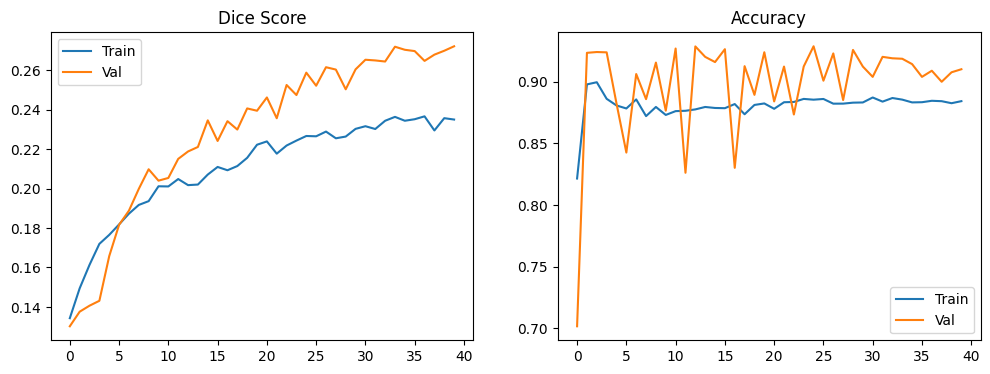

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title("Dice Score")
plt.legend(["Train", "Val"])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


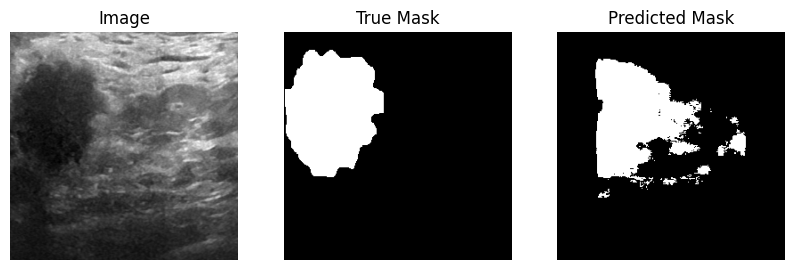

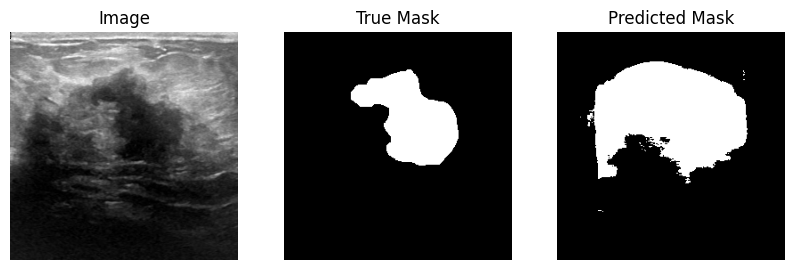

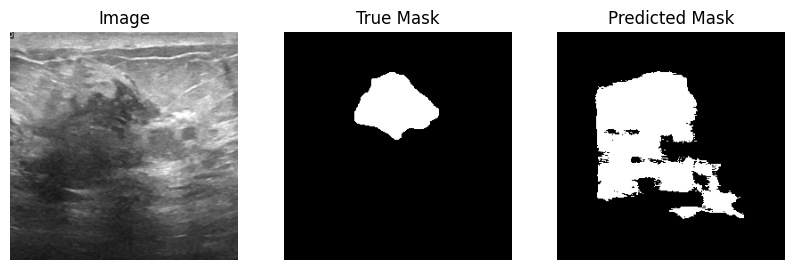

In [14]:
def show_predictions(model, dataset, num=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)

        for i in range(num):
            plt.figure(figsize=(10,4))

            plt.subplot(1,3,1)
            plt.title("Image")
            plt.imshow(images[i].numpy().squeeze(), cmap="gray")
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.title("True Mask")
            plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.title("Predicted Mask")
            plt.imshow(preds[i].squeeze() > 0.4, cmap="gray")   # tuned threshold
            plt.axis("off")

            plt.show()

show_predictions(model, val_dataset)